Scope of the project:
- focused on One-Per-Env baseline comparison
- use just Lotka-Volterra (ODE) and Gray-Scott (PDE) datasets because they're more computationally cheap to simulate using SciPy
- fixed initial conditions (np.random.seed(10))

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial
import pandas as pd

from pydmd import DMD, BOPDMD, EDMD
from pydmd.plotter import plot_eigs
from numpy.fft import fft, fftfreq

import seaborn as sns

### LEADS baselines

In [2]:
lv_mean = 1.16e-3
lv_std = 0.99e-3
gs_mean = 2.08e-3
gs_std = 2.88e-3

print("LEADS Test MSE Results:\n")
print(f"LV - 10 envs - 1 trajectory/env\n{lv_mean:.6f} ± {lv_std:.6f}\n")
print(f"GS - 3 envs - 1 trajectory/env\n{gs_mean:.6f} ± {gs_std:.6f}\n")

LEADS Test MSE Results:

LV - 10 envs - 1 trajectory/env
0.001160 ± 0.000990

GS - 3 envs - 1 trajectory/env
0.002080 ± 0.002880



### 1. Data generation
- simulate 2 environments (eg. change predator/prey interaction parameters for each environment)
- generate 1 training trajectory (20 time steps) and just 3 testing trajectories per environment

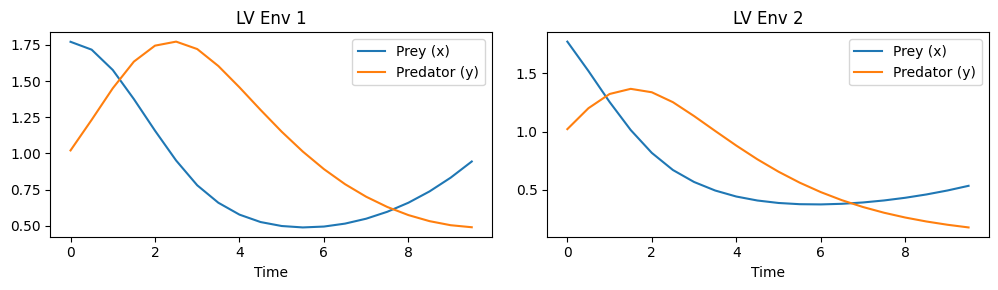

Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)
Shape of gs_trajs[1]: (2, 10, 32, 32)
Shape of lv_trajs[1]: (2, 20)
Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)


In [3]:
# ---- Lotka-Volterra (same params) ----
lv_params = [
    {'alpha': 0.5 , 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
    {'alpha': 0.25, 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
]
lv_time_horizon, lv_dt = 10.0, 0.5
lv_times = np.arange(0, lv_time_horizon, lv_dt)

def lv_rhs(t, x, env):
    p = lv_params[env]
    d = np.zeros(2)
    d[0] = p['alpha'] * x[0] - p['beta'] * x[0] * x[1]
    d[1] = p['delta'] * x[0] * x[1] - p['gamma'] * x[1]
    return d

np.random.seed(10)
y0 = np.random.random(2) + 1.0

lv_trajs = []
for env in range(len(lv_params)):
    res = solve_ivp(partial(lv_rhs, env=env), (0., lv_time_horizon), y0, method='RK45',
                    t_eval=lv_times)
    lv_trajs.append(res.y)  # (2, n_steps); use as snapshot matrix X

# ---- Gray-Scott (same params) ----
gs_params = [
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.037, 'k': 0.060},
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.030, 'k': 0.062},
]
gs_size, gs_dx = 32, 1.0
gs_time_horizon, gs_dt_eval = 400.0, 40.0
gs_n = int(gs_time_horizon / gs_dt_eval)
gs_times = np.arange(0, gs_time_horizon, gs_dt_eval)
gs_n_block = 3

def gs_laplacian2d(a, dx):
    a_nz = np.roll(a, (+1, 0), axis=(0, 1))
    a_pz = np.roll(a, (-1, 0), axis=(0, 1))
    a_zn = np.roll(a, (0, +1), axis=(0, 1))
    a_zp = np.roll(a, (0, -1), axis=(0, 1))
    a_nn = np.roll(a, (+1, +1), axis=(0, 1))
    a_np = np.roll(a, (+1, -1), axis=(0, 1))
    a_pn = np.roll(a, (-1, +1), axis=(0, 1))
    a_pp = np.roll(a, (-1, -1), axis=(0, 1))
    return (-3 * a + 0.5 * (a_nz + a_pz + a_zn + a_zp) + 0.25 * (a_nn + a_np + a_pn + a_pp)) / (dx ** 2)

def gs_rhs(t, uv, env):
    D_u, D_v = gs_params[env]['D_u'], gs_params[env]['D_v']
    F, k = gs_params[env]['F'], gs_params[env]['k']
    u = uv[: gs_size * gs_size].reshape(gs_size, gs_size)
    v = uv[gs_size * gs_size :].reshape(gs_size, gs_size)
    du = D_u * gs_laplacian2d(u, gs_dx) - u * (v ** 2) + F * (1.0 - u)
    dv = D_v * gs_laplacian2d(v, gs_dx) + u * (v ** 2) - (F + k) * v
    return np.concatenate([du.ravel(), dv.ravel()])

# Fixed IC across envs: 3× 2-by-2 squares at random positions
np.random.seed(10)
u0 = 0.95 * np.ones((gs_size, gs_size))
v0 = 0.05 * np.ones((gs_size, gs_size))
r = 2  # 2×2 squares
for _ in range(gs_n_block):
    n0, n1 = np.random.randint(0, gs_size - r, size=2)
    u0[n0 : n0 + r, n1 : n1 + r] = 0.0
    v0[n0 : n0 + r, n1 : n1 + r] = 1.0
uv0 = np.concatenate([u0.ravel(), v0.ravel()])

gs_trajs = []
for env in range(len(gs_params)):
    res = solve_ivp(partial(gs_rhs, env=env), (0., gs_time_horizon), uv0, method='RK45',
                    t_eval=gs_times)
    N2 = gs_size * gs_size
    U = res.y[:N2].T.reshape(-1, gs_size, gs_size)
    V = res.y[N2:].T.reshape(-1, gs_size, gs_size)
    gs_trajs.append(np.stack([U, V], axis=0))  # (2, n, size, size)
    
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i in range(min(2, len(lv_trajs))):
    axes[i].plot(lv_times, lv_trajs[i][0], label='Prey (x)')
    axes[i].plot(lv_times, lv_trajs[i][1], label='Predator (y)')
    axes[i].set_title(f'LV Env {i+1}')
    axes[i].set_xlabel('Time')
    axes[i].legend()
plt.tight_layout()
plt.show()

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)
print("Shape of gs_trajs[1]:", gs_trajs[1].shape)
print("Shape of lv_trajs[1]:", lv_trajs[1].shape)

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)

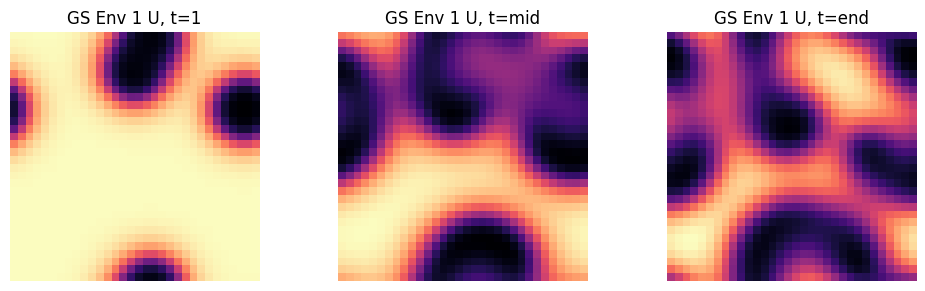

In [4]:
# Visualize GS spatial fields: use axes[i] and 2D slices of gs_trajs[env]
# gs_trajs[env] has shape (2, n, gs_size, gs_size) -> [channel U/V, time, x, y]
env = 0  # which environment to plot
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
# Show U at t=1, t=mid, t=end (use axes[0], axes[1], axes[2])
axes[0].imshow(gs_trajs[env][0, 1], cmap='magma')
axes[0].set_title(f"GS Env {env+1} U, t=1")
axes[0].axis('off')
axes[1].imshow(gs_trajs[env][0, gs_n // 2], cmap='magma')
axes[1].set_title(f"GS Env {env+1} U, t=mid")
axes[1].axis('off')
axes[2].imshow(gs_trajs[env][0, -1], cmap='magma')
axes[2].set_title(f"GS Env {env+1} U, t=end")
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 2. Noise injection
- add small amount of Gaussian noise to training snapshot matrices to simulate real-world conditions

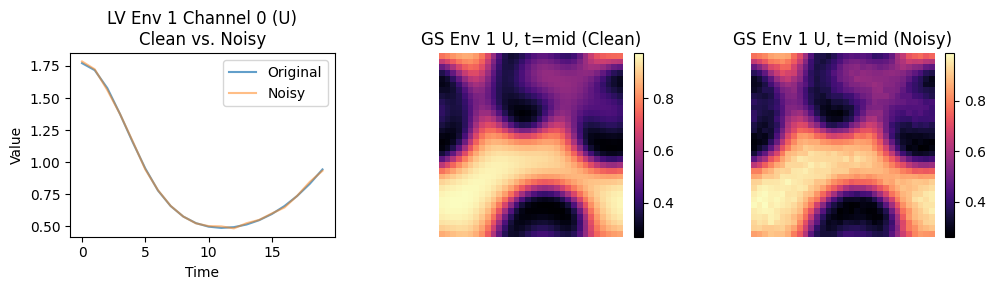

In [5]:
# Add Gaussian noise to the one training trajectory per env
sigma = 0.01
np.random.seed(10)

lv_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in lv_trajs]
gs_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in gs_trajs]

# Use lv_trajs_noisy / gs_trajs_noisy for DMD fitting; keep lv_trajs / gs_trajs for evaluation

env = 0  # choose first environment
channel = 0  # U in LV/GS (can try 1 for V)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# LV: plot time series of U, noisy vs original
axes[0].plot(lv_trajs[env][channel], label="Original", alpha=0.7)
axes[0].plot(lv_trajs_noisy[env][channel], label="Noisy", alpha=0.5)
axes[0].set_title(f"LV Env {env+1} Channel {channel} (U)\nClean vs. Noisy")
axes[0].legend()
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")

# GS: plot single-spatial field at t=mid (original vs noisy)
mid = gs_trajs[env].shape[1] // 2

im1 = axes[1].imshow(gs_trajs[env][0, mid], cmap="magma")
axes[1].set_title(f"GS Env {env+1} U, t=mid (Clean)")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(gs_trajs_noisy[env][0, mid], cmap="magma")
axes[2].set_title(f"GS Env {env+1} U, t=mid (Noisy)")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 3. Model Fitting (One-Per-Env Strategy)
For each environment, feed the noisy training trajectory into three separate PyDMD models (fit independently per environment; do not mix data—this replicates the "One-Per-Env" baseline):
- **DMD()** — Exact DMD
- **BOPDMD(num_trials=0)** — Optimized DMD
- **EDMD()** — Extended DMD with polynomial dictionary

Reconstructions are visualized below for LV (phase portrait + time series) and GS (snapshots at selected times).

Env 1: omega=0.6283  period=10.00  periods_in_data=0.95


/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


Env 2: omega=0.6283  period=10.00  periods_in_data=0.95


/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)



Fitted 2 LV environments.

── Initial conditions ──
  True x0:    [1.77132064 1.02075195]
  DMD x0:     [1.78463651 1.00097467]
  BOPDMD x0:  [1.41552675 1.20718639]
  EDMD x0:    [1.78463651 1.00097467]

── BOPDMD eigenvalues: [0.-0.54486924j 0.+0.54486924j]

── MSE (vs clean ground truth) ──
  DMD:    0.0951
  BOPDMD: 0.0145
  EDMD:   0.0030


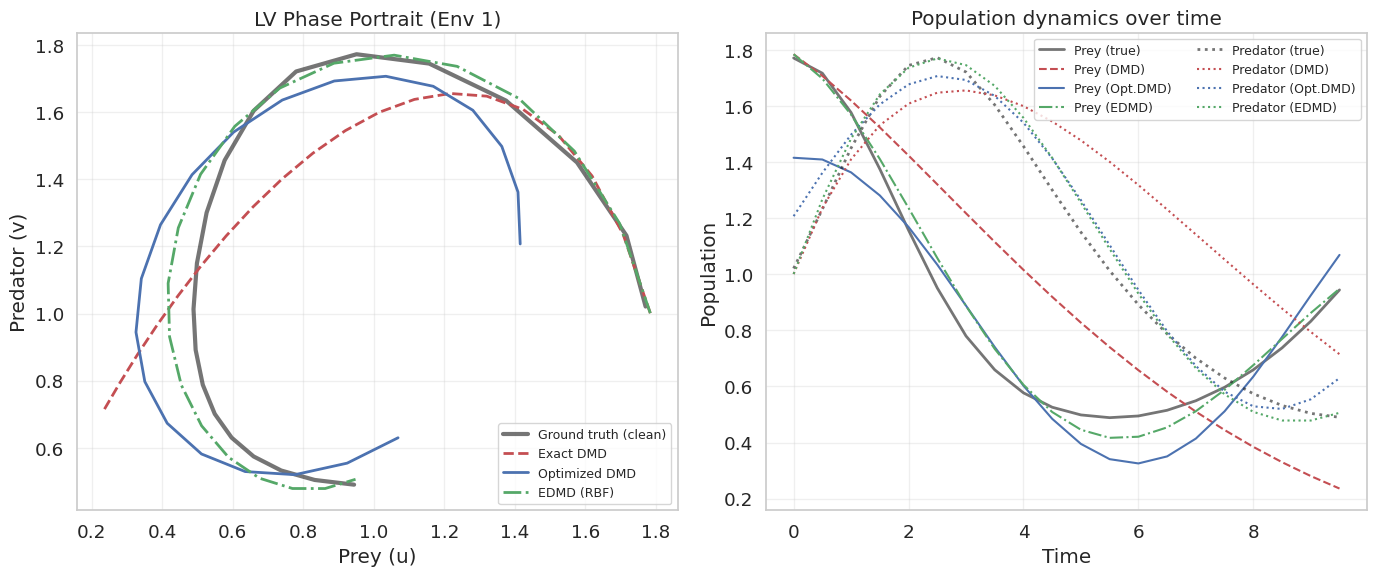

In [37]:
models_lv = []

for lv_env in range(len(lv_params)):

    # ground truth + noisy data (from pre-noised trajectories) ──
    X_lv_dense  = lv_trajs[lv_env]        # clean ground truth
    X_lv_noisy  = lv_trajs_noisy[lv_env]  # pre-noised (sigma=0.01, seed=10)
    t_dense     = lv_times

    # normalize 
    X_mean = X_lv_noisy.mean(axis=1, keepdims=True)
    X_std  = X_lv_noisy.std(axis=1, keepdims=True)
    X_std  = np.maximum(X_std, 1e-10)
    X_norm = (X_lv_noisy - X_mean) / X_std

    # FFT omega estimate 
    signal = X_norm[0]
    n      = len(signal)
    dt     = t_dense[1] - t_dense[0]
    freqs  = fftfreq(n, d=dt)
    power  = np.abs(fft(signal))
    pos    = freqs > 0
    omega  = 2 * np.pi * freqs[pos][np.argmax(power[pos])]
    period = 2 * np.pi / omega
    print(f"Env {lv_env+1}: omega={omega:.4f}  period={period:.2f}  periods_in_data={t_dense[-1]/period:.2f}")

    # fit models 
    dmd = DMD(svd_rank=3)
    dmd.fit(X_lv_noisy)

    bopdmd = BOPDMD(
        svd_rank=3,
        num_trials=50,
        trial_size=0.8,
        eig_constraints={"imag", "conjugate_pairs"},
        init_alpha=np.array([1j * omega, -1j * omega]),
        varpro_opts_dict={
            "tol":       1e-4,
            "maxiter":   500,
            "eps_stall": 1e-8,
            "maxlam":    52,
            "lamup":     1.5,
            "verbose":   False,
        }
    )
    bopdmd.fit(X_norm, t=t_dense)

    edmd = EDMD(svd_rank=3, kernel_metric="rbf", kernel_params={"gamma": 0.5})
    edmd.fit(X_lv_noisy)

    # store 
    models_lv.append({
        "DMD":    dmd,
        "BOPDMD": bopdmd,
        "EDMD":   edmd,
        "X_mean": X_mean,
        "X_std":  X_std,
    })

print(f"\nFitted {len(models_lv)} LV environments.")

# diagnostics + Plot for env 0 
lv_env = 0
X_lv_dense  = lv_trajs[lv_env]
X_lv_noisy  = lv_trajs_noisy[lv_env]
t_dense     = lv_times
X_mean      = models_lv[lv_env]["X_mean"]
X_std       = models_lv[lv_env]["X_std"]

dmd    = models_lv[lv_env]["DMD"]
bopdmd = models_lv[lv_env]["BOPDMD"]
edmd   = models_lv[lv_env]["EDMD"]

X_dmd_pred  = dmd.reconstructed_data.real
X_bop_norm  = bopdmd.reconstructed_data.real
X_bop_pred  = (X_bop_norm * X_std) + X_mean
X_edmd_full = edmd.reconstructed_data.real
X_edmd_pred = X_edmd_full[:2] if X_edmd_full.shape[0] > 2 else X_edmd_full

print("\n── Initial conditions ──")
print(f"  True x0:    {X_lv_dense[:, 0]}")
print(f"  DMD x0:     {X_dmd_pred[:, 0]}")
print(f"  BOPDMD x0:  {X_bop_pred[:, 0]}")
print(f"  EDMD x0:    {X_edmd_pred[:, 0]}")
print(f"\n── BOPDMD eigenvalues: {bopdmd.eigs}")

min_len = min(X_lv_dense.shape[1], X_bop_pred.shape[1], X_dmd_pred.shape[1])
print(f"\n── MSE (vs clean ground truth) ──")
print(f"  DMD:    {np.mean((X_lv_dense[:, :min_len] - X_dmd_pred[:, :min_len])**2):.4f}")
print(f"  BOPDMD: {np.mean((X_lv_dense[:, :min_len] - X_bop_pred[:, :min_len])**2):.4f}")
print(f"  EDMD:   {np.mean((X_lv_dense[:, :min_len] - X_edmd_pred[:, :min_len])**2):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(X_lv_dense[0],  X_lv_dense[1],  "k-",  lw=3, alpha=0.6, label="Ground truth (clean)")
axes[0].plot(X_dmd_pred[0],  X_dmd_pred[1],  "r--", lw=2,            label="Exact DMD")
axes[0].plot(X_bop_pred[0],  X_bop_pred[1],  "b-",  lw=2,            label="Optimized DMD")
axes[0].plot(X_edmd_pred[0], X_edmd_pred[1], "g-.", lw=2,            label="EDMD (RBF)")
axes[0].set_xlabel("Prey (u)"); axes[0].set_ylabel("Predator (v)")
axes[0].set_title(f"LV Phase Portrait (Env {lv_env+1})")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Prey population
axes[1].plot(t_dense, X_lv_dense[0], "k-",  lw=2, alpha=0.6, label="Prey (true)")
axes[1].plot(t_dense[:min_len], X_dmd_pred[0,  :min_len], "r--", lw=1.5, label="Prey (DMD)")
axes[1].plot(t_dense[:min_len], X_bop_pred[0,  :min_len], "b-",  lw=1.5, label="Prey (Opt.DMD)")
axes[1].plot(t_dense[:min_len], X_edmd_pred[0, :min_len], "g-.", lw=1.5, label="Prey (EDMD)")

# Predator population
axes[1].plot(t_dense, X_lv_dense[1], "k:",  lw=2, alpha=0.6, label="Predator (true)")
axes[1].plot(t_dense[:min_len], X_dmd_pred[1,  :min_len], "r:",  lw=1.5, label="Predator (DMD)")
axes[1].plot(t_dense[:min_len], X_bop_pred[1,  :min_len], "b:",  lw=1.5, label="Predator (Opt.DMD)")
axes[1].plot(t_dense[:min_len], X_edmd_pred[1, :min_len], "g:",  lw=1.5, label="Predator (EDMD)")

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Population")

axes[1].set_title("Population dynamics over time")
axes[1].legend(fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Find best gamma

In [7]:
for gamma in [0.1, 0.5, 1.0, 2.0, 5.0]:
    e = EDMD(svd_rank=3, kernel_metric="rbf", kernel_params={"gamma": gamma})
    e.fit(X_lv_noisy)
    pred = e.reconstructed_data.real[:2]
    mse = np.mean((X_lv_dense[:, :pred.shape[1]] - pred)**2)
    print(f"gamma={gamma} → MSE={mse:.4f}")

gamma=0.1 → MSE=0.3809
gamma=0.5 → MSE=0.0030
gamma=1.0 → MSE=0.0639
gamma=2.0 → MSE=0.1706
gamma=5.0 → MSE=0.4566


In [8]:
models_gs = []

for gs_env in range(len(gs_params)):

    # reshape noisy GS trajectory into snapshot matrix 
    X_gs_3d = np.moveaxis(gs_trajs_noisy[gs_env], 1, -1)  # (2, n, size, size) → (2, size, size, n)
    X       = X_gs_3d.reshape(-1, gs_n)                    # (2*size*size, n)
    X_clean = np.moveaxis(gs_trajs[gs_env], 1, -1).reshape(-1, gs_n)  # clean reference

    # normalize 
    X_mean = X.mean(axis=1, keepdims=True)
    X_std  = X.std(axis=1, keepdims=True)
    X_std  = np.maximum(X_std, 1e-10)
    X_norm = (X - X_mean) / X_std

    t_norm = gs_times / np.max(gs_times)

    # fit models 
    dmd = DMD(svd_rank=3)
    dmd.fit(X)

    initial_guess = np.array([2 * np.pi * 1j, -2 * np.pi * 1j])

    bopdmd = BOPDMD(
        svd_rank=2,
        num_trials=50,
        trial_size=0.8,
        eig_constraints={"imag", "conjugate_pairs"},
        init_alpha=initial_guess,
        varpro_opts_dict={
            "tol":       1e-4,
            "maxiter":   500,
            "eps_stall": 1e-8,
            "maxlam":    52,
            "lamup":     1.5,
            "verbose":   False,
        },
    )
    bopdmd.fit(X_norm, t=t_norm)

    edmd = EDMD(svd_rank=3, kernel_metric="rbf", kernel_params={"gamma": 0.5})
    edmd.fit(X)

    models_gs.append({
        "DMD":     dmd,
        "BOPDMD":  bopdmd,
        "EDMD":    edmd,
        "X_mean":  X_mean,
        "X_std":   X_std,
        "X_clean": X_clean,  # stored for MSE evaluation
    })

print(f"Fitted {len(models_gs)} GS environments.")

# diagnostics for env 0 
gs_env  = 0
X_mean  = models_gs[gs_env]["X_mean"]
X_std   = models_gs[gs_env]["X_std"]
X_clean = models_gs[gs_env]["X_clean"]

dmd    = models_gs[gs_env]["DMD"]
bopdmd = models_gs[gs_env]["BOPDMD"]
edmd   = models_gs[gs_env]["EDMD"]

X_dmd_pred  = dmd.reconstructed_data.real
X_bop_norm  = bopdmd.reconstructed_data.real
X_bop_pred  = (X_bop_norm * X_std) + X_mean
X_edmd_full = edmd.reconstructed_data.real
X_edmd_pred = X_edmd_full[:X_clean.shape[0]]

min_len = min(X_clean.shape[1], X_dmd_pred.shape[1], X_bop_pred.shape[1], X_edmd_pred.shape[1])
print(f"\n── MSE (vs clean ground truth, Env {gs_env+1}) ──")
print(f"  DMD:    {np.mean((X_clean[:, :min_len] - X_dmd_pred[:, :min_len])**2):.6f}")
print(f"  BOPDMD: {np.mean((X_clean[:, :min_len] - X_bop_pred[:, :min_len])**2):.6f}")
print(f"  EDMD:   {np.mean((X_clean[:, :min_len] - X_edmd_pred[:, :min_len])**2):.6f}")
print(f"\n── BOPDMD eigenvalues: {bopdmd.eigs}")

/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1500987580823867.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/bopdmd.py:973: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 308438154167509.7. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/vattanary/Documents/data-driven dynamical systems/LEADS/.venv/lib/python3.10/site-packages/pydmd/

Fitted 2 GS environments.

── MSE (vs clean ground truth, Env 1) ──
  DMD:    0.001737
  BOPDMD: 0.004493
  EDMD:   0.082739

── BOPDMD eigenvalues: [0.-4.63831585j 0.+4.63831585j]


### 4. Visualization
- **3×3 grid:** `plot_summary` (eigenvalues + spatial modes) for **Gray-Scott** only—suited to PDE/spatiotemporal data.
- **2D phase portrait (LV):** Exact DMD vs Optimized DMD (BOPDMD) on the Lotka–Volterra phase plane (centerpiece: noise sensitivity vs denoising).

/tmp/ipykernel_261345/2122286478.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1]); plt.show()


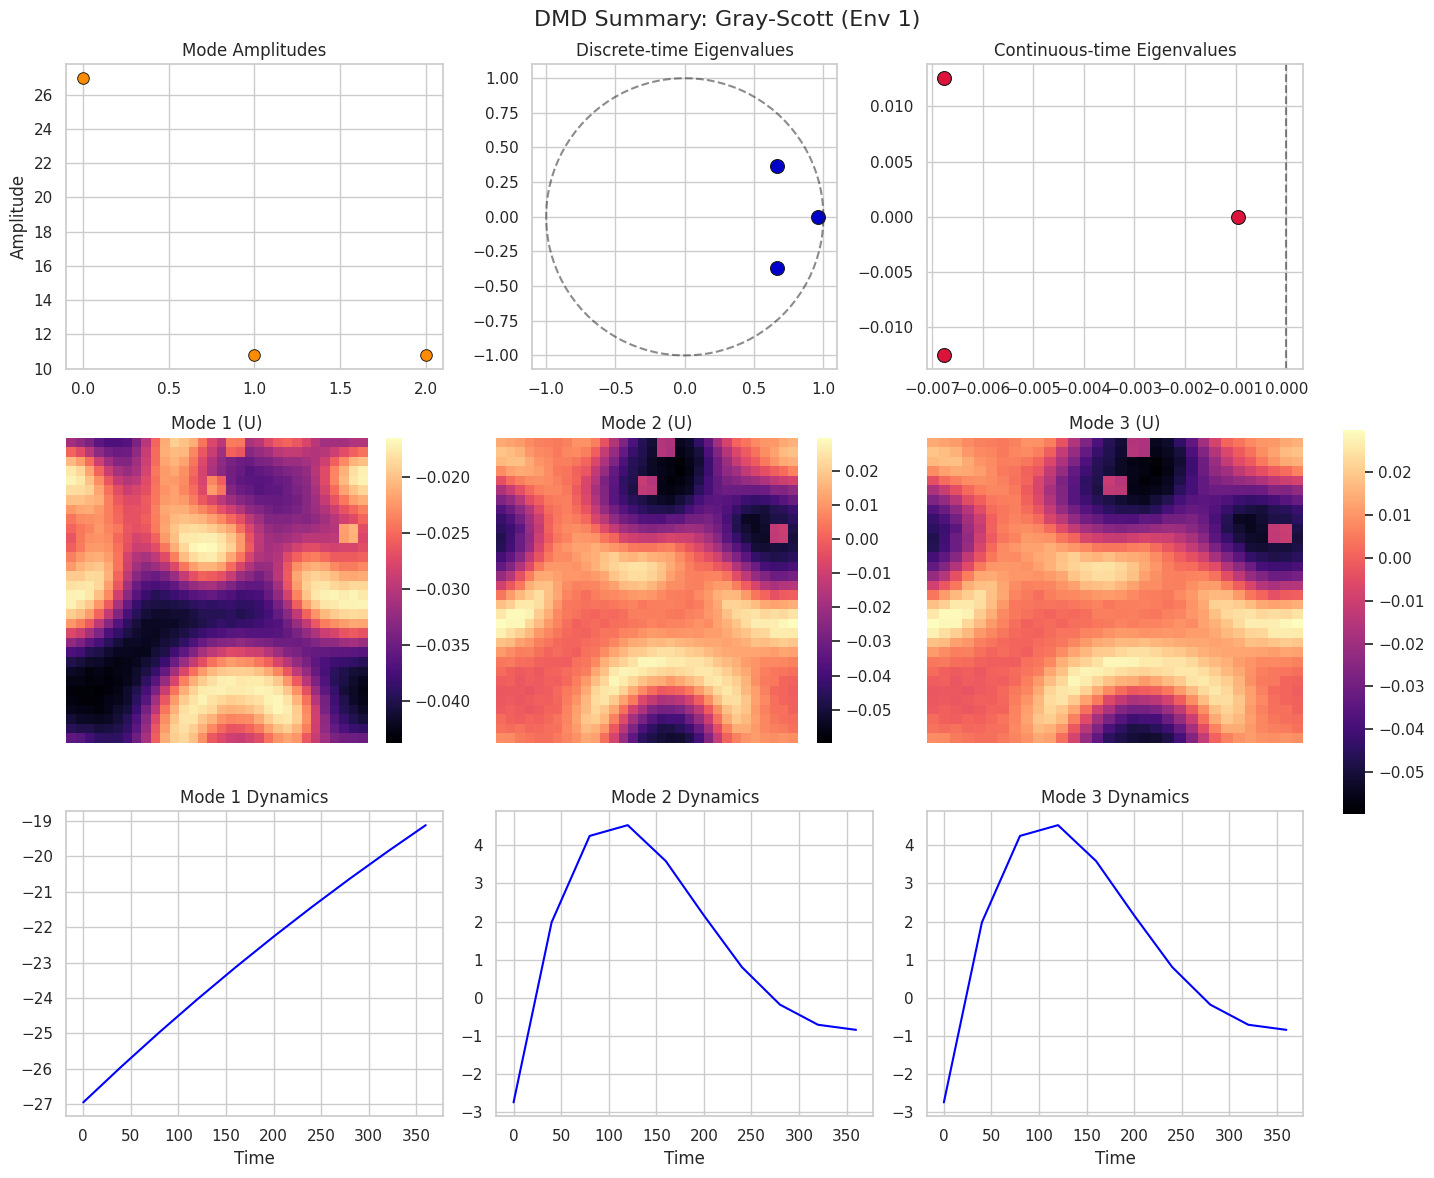

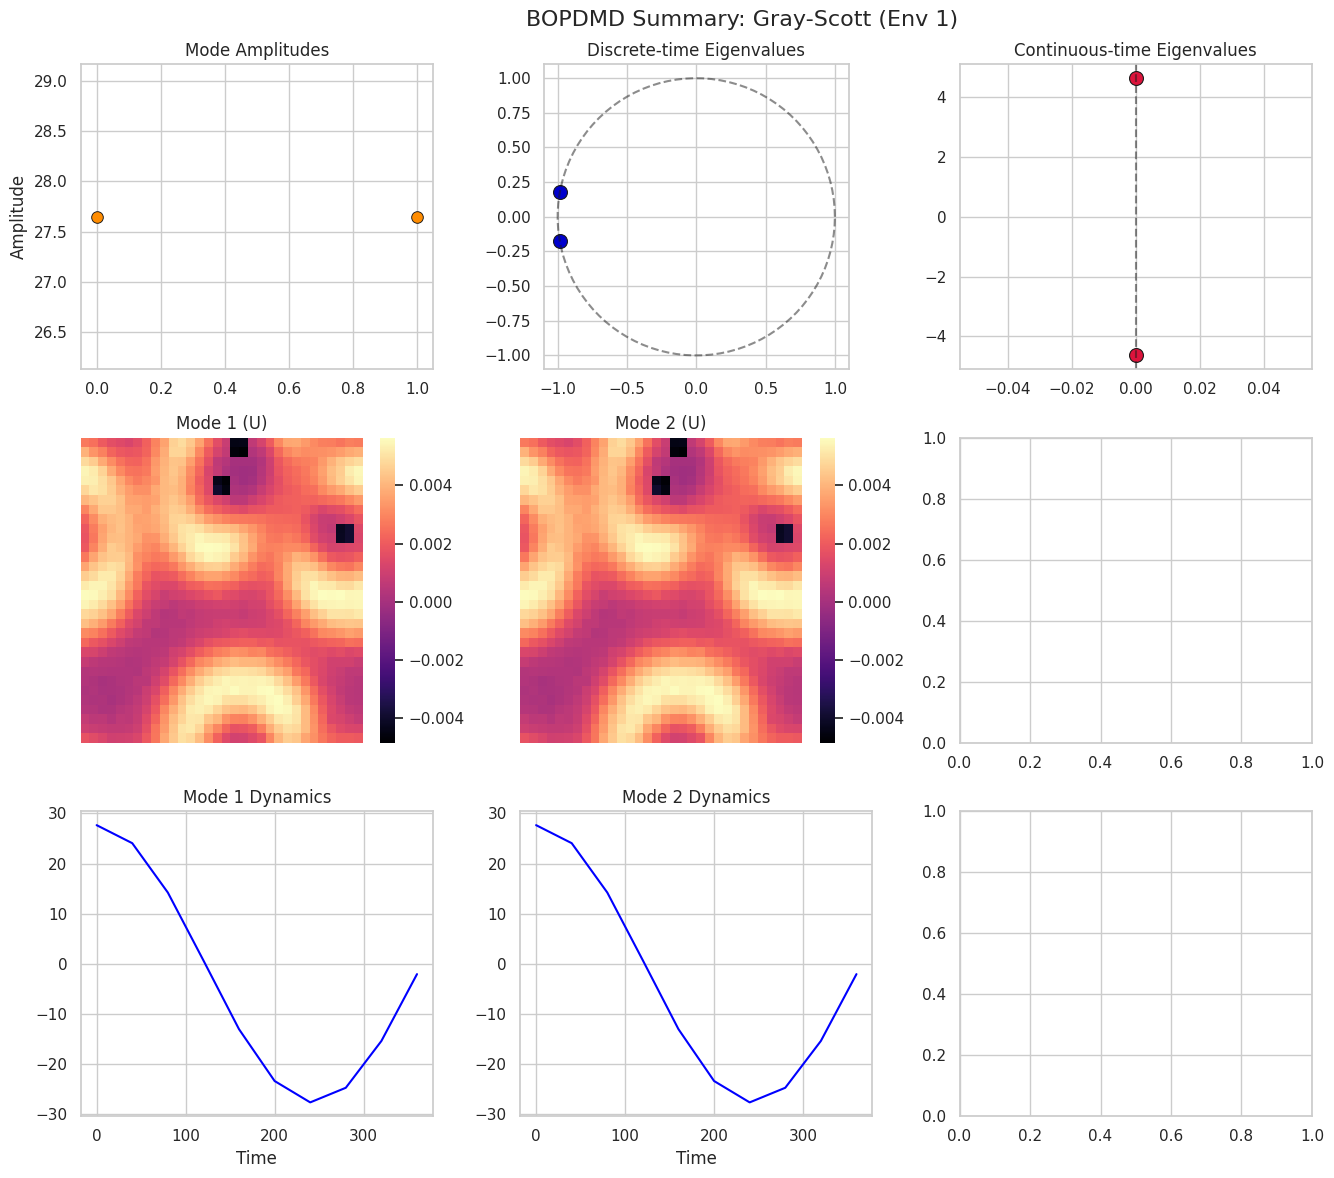

/tmp/ipykernel_261345/2122286478.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1]); plt.show()


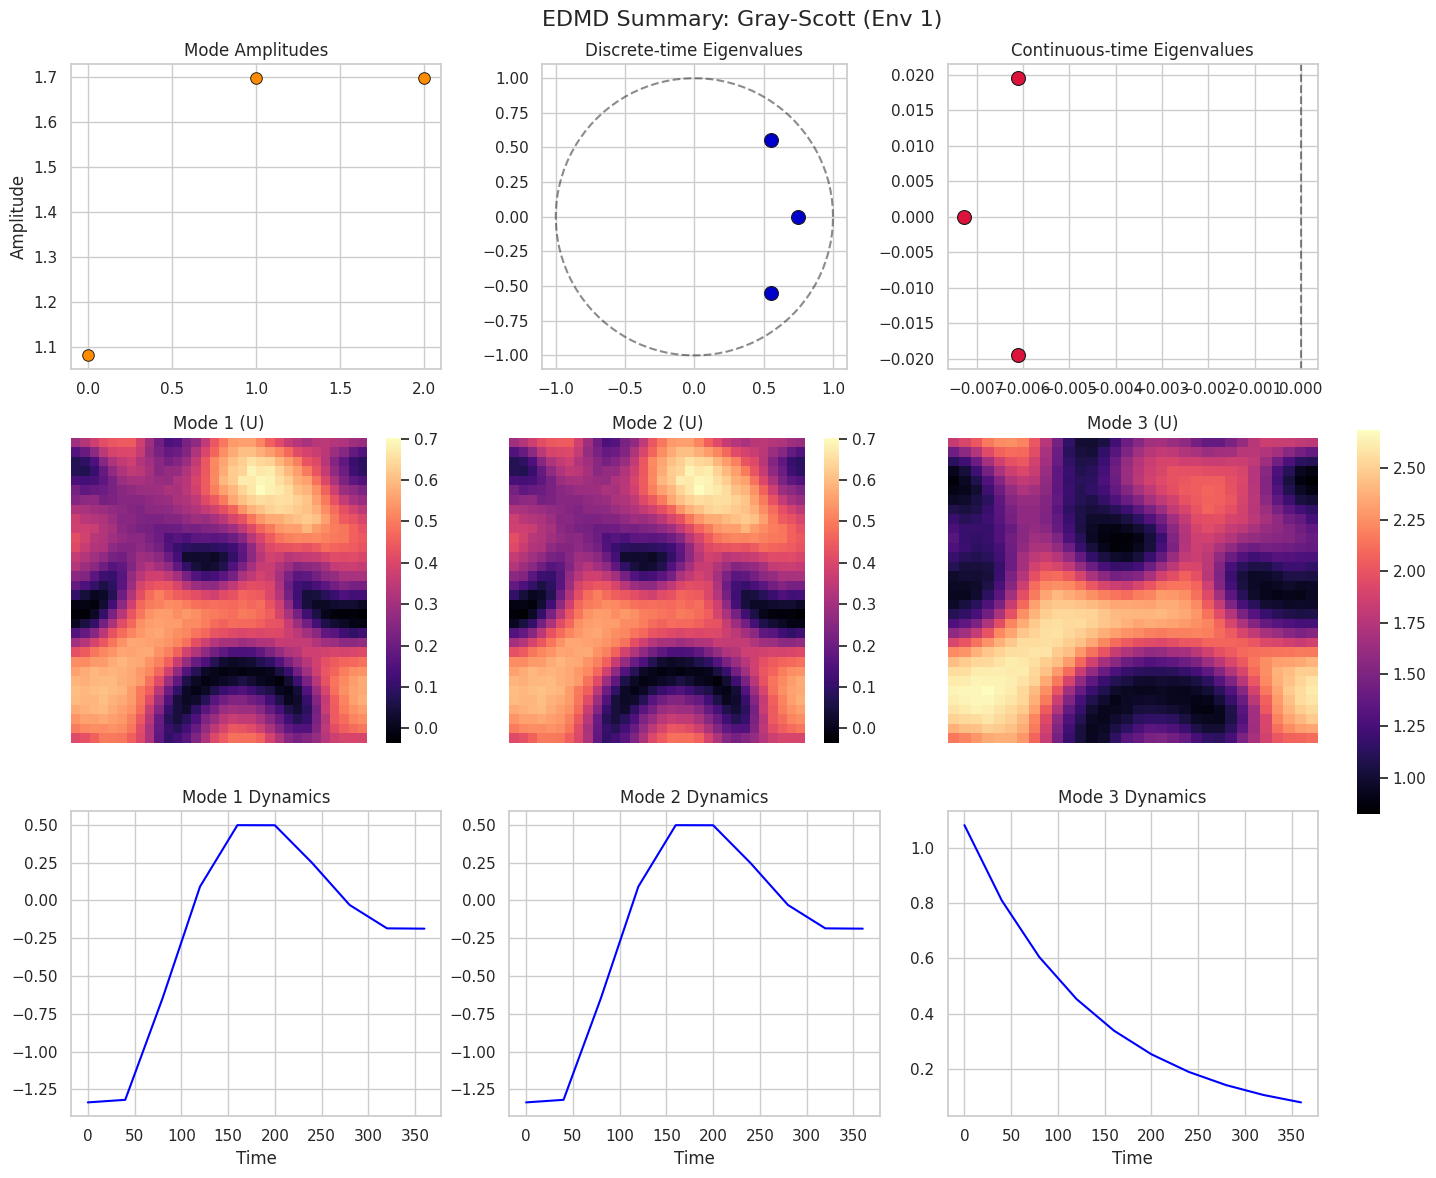

/tmp/ipykernel_261345/2122286478.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1]); plt.show()


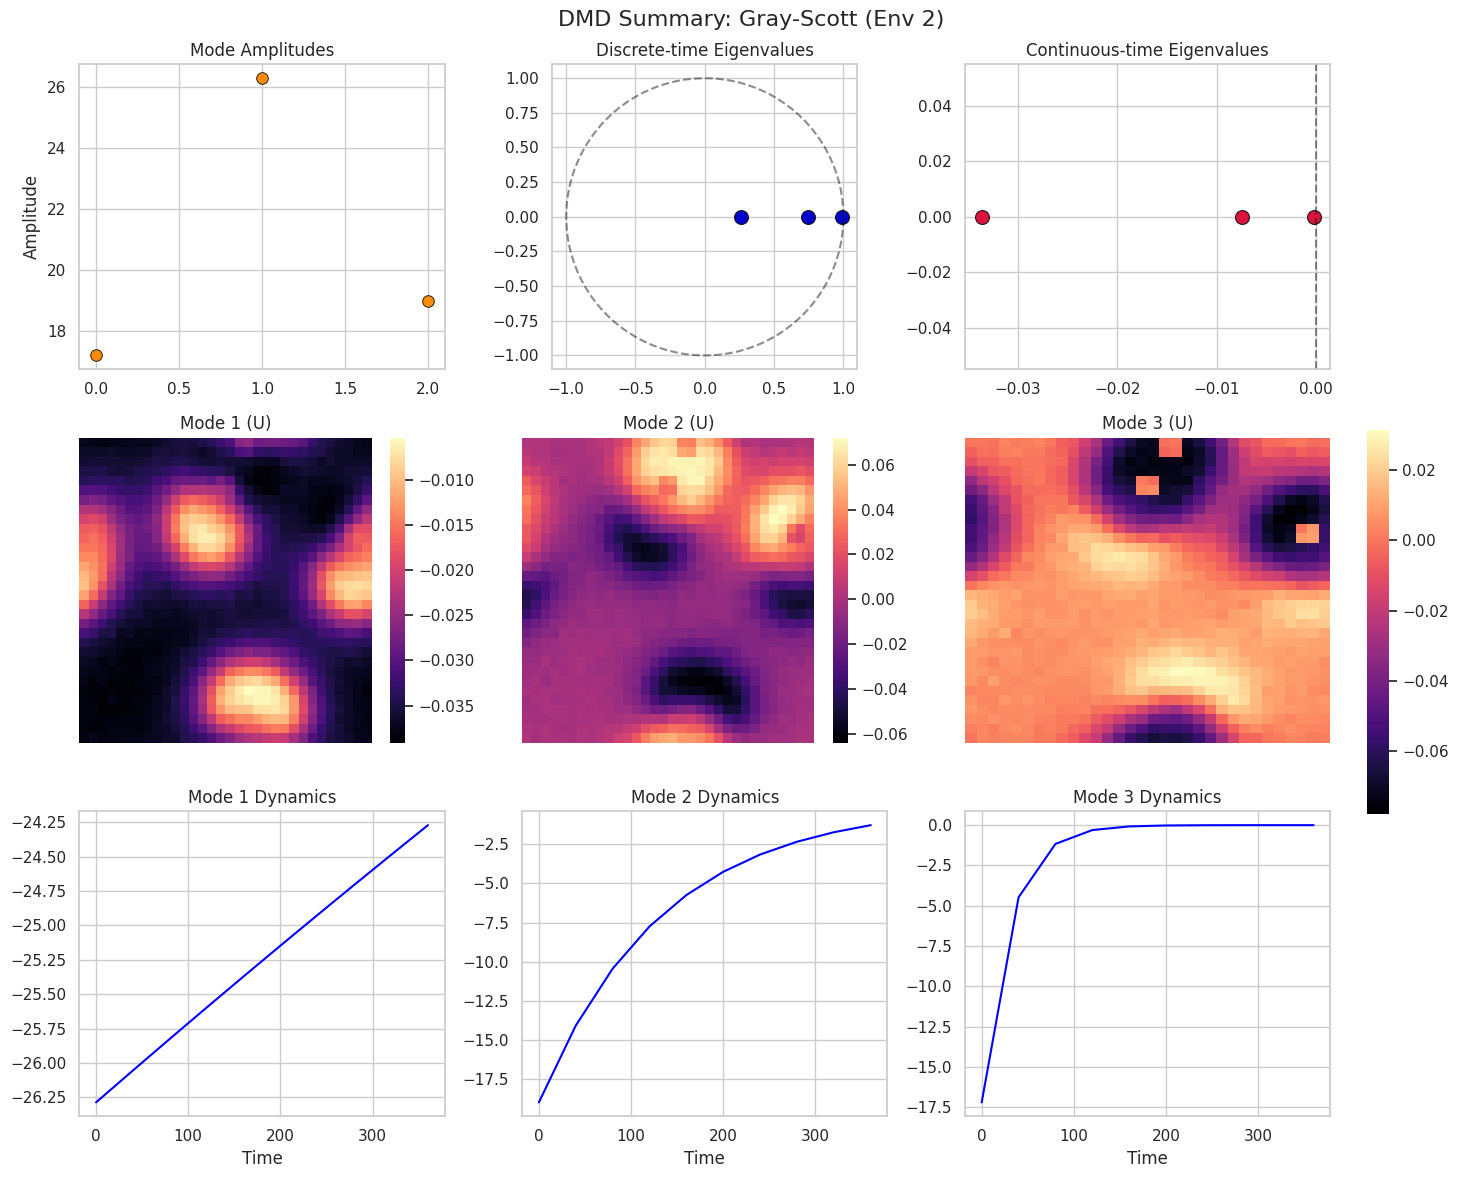

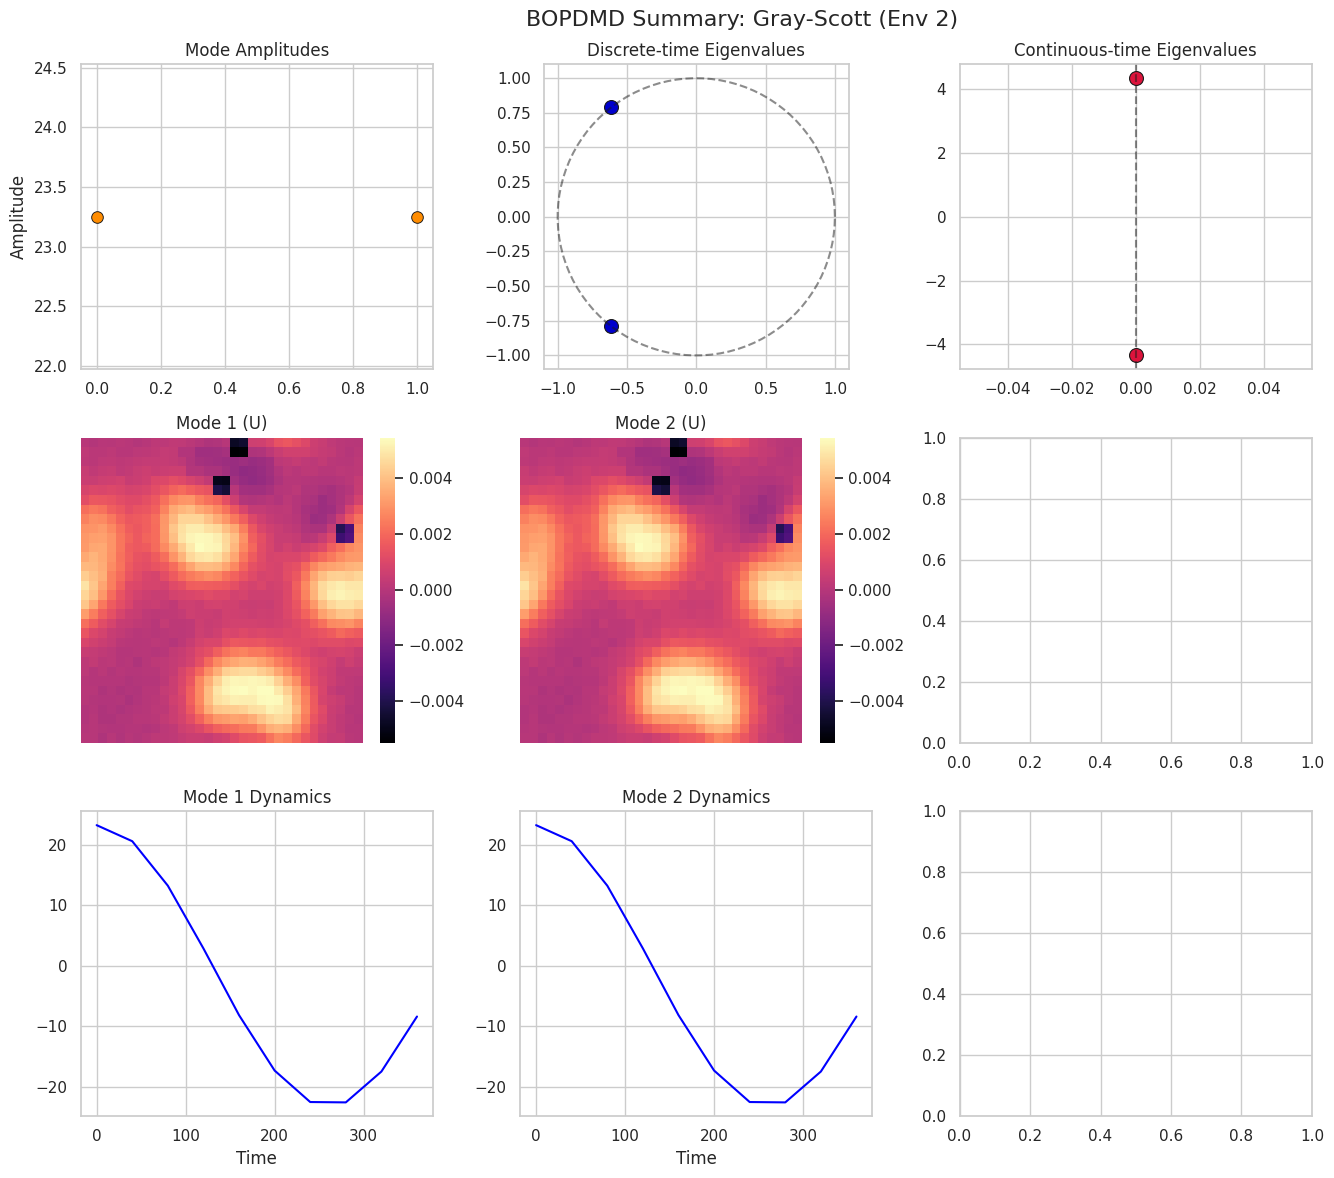

/tmp/ipykernel_261345/2122286478.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, .9, 1]); plt.show()


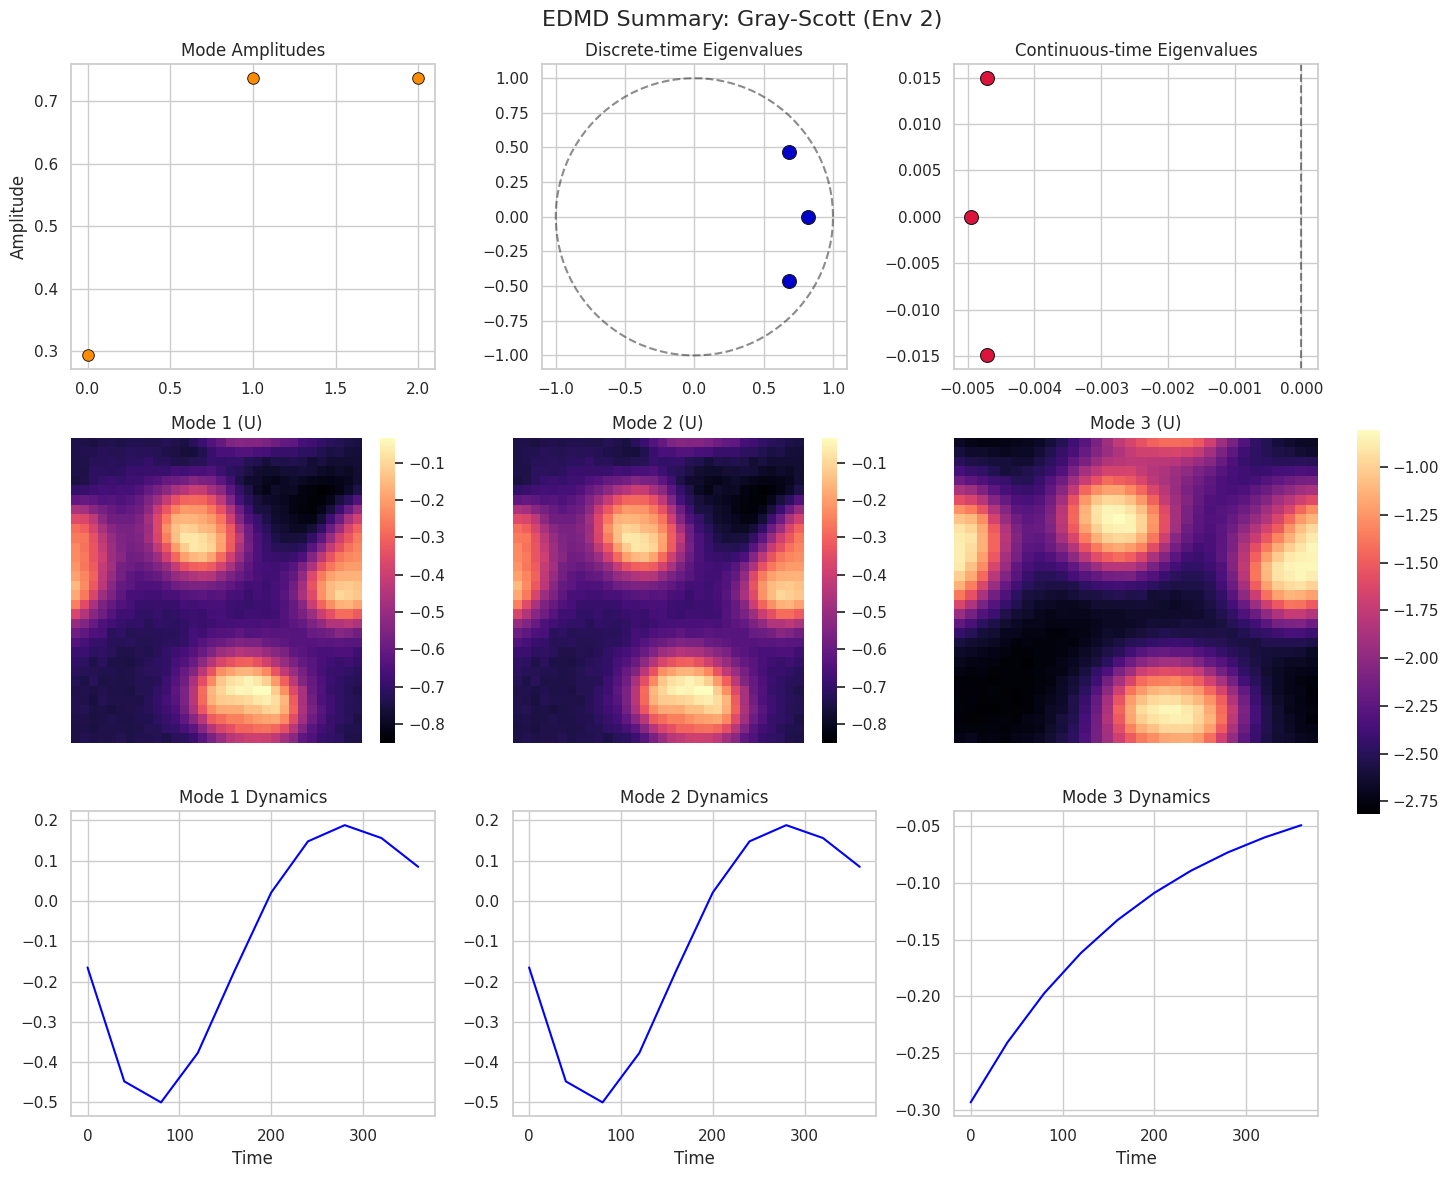

In [39]:
def plot_gs_summary(model, name, gs_env, gs_times, gs_dt_eval, gs_size,
                    X_mean=None, X_std=None):
    """3×3 summary for a fitted PyDMD model on Gray-Scott: amplitudes, eigs (discrete/continuous), modes, dynamics."""
    is_bopdmd = name == "BOPDMD"
    amplitudes = np.abs(model.amplitudes)
    modes_plot = (model.modes * X_std) if (is_bopdmd and X_std is not None) else model.modes
    eigs_d = np.exp(model.eigs * gs_dt_eval) if is_bopdmd else model.eigs
    eigs_c = model.eigs if is_bopdmd else np.log(model.eigs) / gs_dt_eval

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    sns.scatterplot(x=np.arange(len(amplitudes)), y=amplitudes, ax=axes[0, 0], s=70, color="darkorange", edgecolor="k")
    axes[0, 0].set_title("Mode Amplitudes"); axes[0, 0].set_ylabel("Amplitude")

    theta = np.linspace(0, 2 * np.pi, 100)
    axes[0, 1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5)
    sns.scatterplot(x=eigs_d.real, y=eigs_d.imag, ax=axes[0, 1], s=100, color="mediumblue", edgecolor="k")
    axes[0, 1].set_title("Discrete-time Eigenvalues"); axes[0, 1].set_aspect("equal")

    # Continuous eigs
    sns.scatterplot(x=eigs_c.real, y=eigs_c.imag, ax=axes[0, 2], s=100, color="crimson", edgecolor="k")
    axes[0, 2].axvline(0, color="k", linestyle="--", alpha=0.5)
    axes[0, 2].set_title("Continuous-time Eigenvalues")

    # Spatial modes (show U component)
    for i in range(min(3, modes_plot.shape[1])):
        idx = np.argsort(amplitudes)[::-1][i]
        mode_2d = modes_plot[:, idx].reshape(2, gs_size, gs_size)
        # Use seaborn heatmap for mode visualization
        sns.heatmap(mode_2d[0].real, ax=axes[1, i], cmap="magma", cbar=True, 
                    cbar_ax=None if i != 2 else fig.add_axes([.91, .31, .015, .32]),
                    xticklabels=False, yticklabels=False)
        axes[1, i].set_title(f"Mode {i+1} (U)"); axes[1, i].axis("off")

    # Mode dynamics
    for i in range(min(3, modes_plot.shape[1])):
        idx = np.argsort(amplitudes)[::-1][i]
        sns.lineplot(x=gs_times, y=model.dynamics[idx, :].real, ax=axes[2, i], color="blue")
        axes[2, i].set_title(f"Mode {i+1} Dynamics"); axes[2, i].set_xlabel("Time")

    plt.suptitle(f"{name} Summary: Gray-Scott (Env {gs_env+1})", fontsize=16)
    plt.tight_layout(rect=[0, 0, .9, 1]); plt.show()


for gs_env in range(len(gs_params)):
    X_mean = models_gs[gs_env]["X_mean"]
    X_std  = models_gs[gs_env]["X_std"]

    for name in ("DMD", "BOPDMD", "EDMD"):
        plot_gs_summary(
            model      = models_gs[gs_env][name],
            name       = name,
            gs_env     = gs_env,
            gs_times   = gs_times,
            gs_dt_eval = gs_dt_eval,
            gs_size    = gs_size,
            X_mean     = X_mean,
            X_std      = X_std,
        )

### 5. Evaluation

GS True Test MSE (avg across envs and trajectories):
  DMD     : 0.057846
  BOPDMD  : 0.111496
  EDMD    : 0.169727
LV True Test MSE (avg across envs): {'DMD': 0.10008969282750219, 'BOPDMD': 0.20218727637133707, 'EDMD': 0.015904184935780028}
GS True Test MSE (avg across envs): {'DMD': 0.057845825151366936, 'BOPDMD': 0.1114961549646752, 'EDMD': 0.16972704701301647}


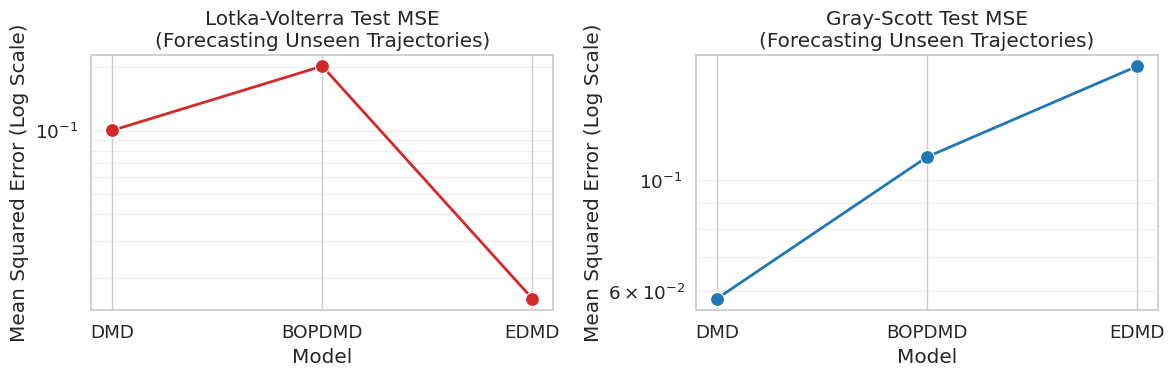

LV  Test MSE: {'DMD': 0.10008969282750219, 'BOPDMD': 0.20218727637133707, 'EDMD': 0.015904184935780028}
GS  Test MSE: {'DMD': 0.057845825151366936, 'BOPDMD': 0.1114961549646752, 'EDMD': 0.16972704701301647}

Test MSE Comparison (DMD vs. LEADS):

        Model        LV Test MSE        GS Test MSE
          DMD           0.100090           0.057846
       BOPDMD           0.202187           0.111496
         EDMD           0.015904           0.169727
LEADS (paper) 0.001160 ± 9.9e-04 0.002080 ± 2.9e-03


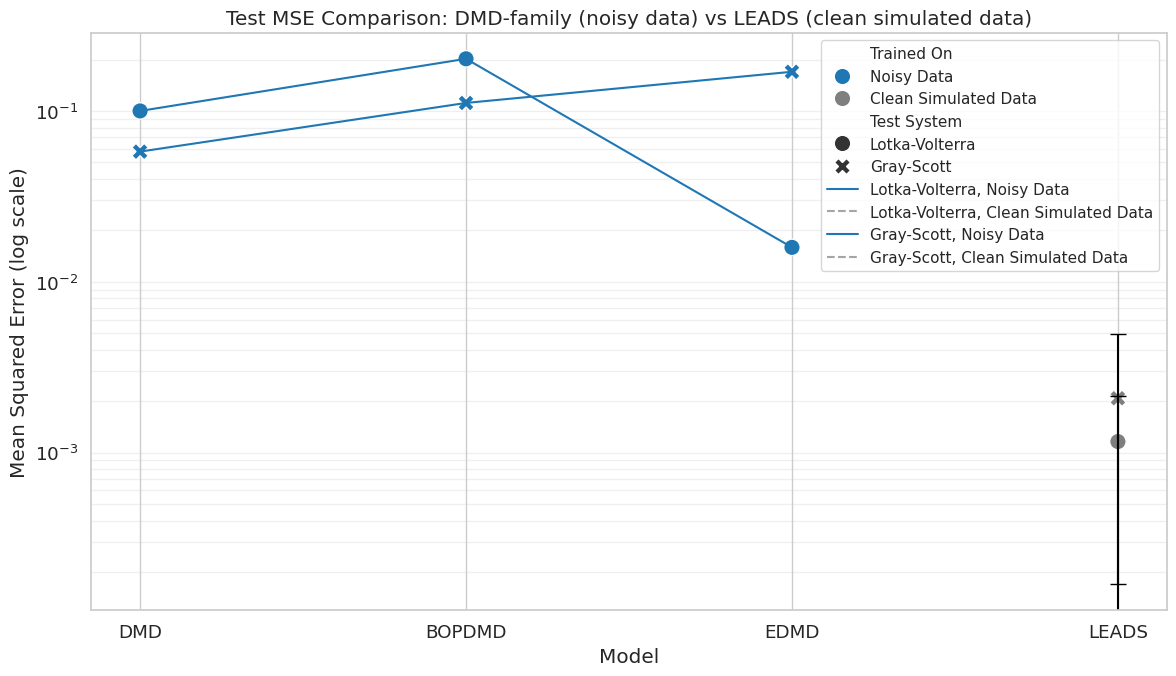

In [38]:
n_test_trajs = 3
np.random.seed(99) # New seed for testing data

# Lotka-Volterra Test Initial Conditions
lv_test_ic = [np.random.random(2) + 1.0 for _ in range(n_test_trajs)]

lv_test_trajs = [] # Shape: (envs, test_trajs, states, time)
for env in range(len(lv_params)):
    env_trajs = []
    for i in range(n_test_trajs):
        res = solve_ivp(partial(lv_rhs, env=env), (0., lv_time_horizon), lv_test_ic[i], 
                        method='RK45', t_eval=lv_times)
        env_trajs.append(res.y) 
    lv_test_trajs.append(env_trajs)

# Gray-Scott Test Initial Conditions
gs_test_ic = []
for _ in range(n_test_trajs):
    u0 = 0.95 * np.ones((gs_size, gs_size))
    v0 = 0.05 * np.ones((gs_size, gs_size))
    for _ in range(gs_n_block):
        r = 2
        n0, n1 = np.random.randint(0, gs_size - r, size=2)
        u0[n0 : n0 + r, n1 : n1 + r] = 0.0
        v0[n0 : n0 + r, n1 : n1 + r] = 1.0
    gs_test_ic.append(np.concatenate([u0.ravel(), v0.ravel()]))

gs_test_trajs = [] # Shape: (envs, test_trajs, flattened_states, time)
for env in range(len(gs_params)):
    env_trajs = []
    for i in range(n_test_trajs):
        res = solve_ivp(partial(gs_rhs, env=env), (0., gs_time_horizon), gs_test_ic[i], 
                        method='RK45', t_eval=gs_times)
        # Re-apply the NumPy moveaxis reshaping logic for GS spatial data
        X_gs_3d = np.moveaxis(np.stack([res.y[:gs_size**2].T.reshape(-1, gs_size, gs_size), 
                                        res.y[gs_size**2:].T.reshape(-1, gs_size, gs_size)], axis=0), 1, -1)
        X_gs = X_gs_3d.reshape(-1, gs_n)
        env_trajs.append(X_gs)
    gs_test_trajs.append(env_trajs)

def forecast_dmd(model, x0_test):
    """DMD forecast from new IC: x(t) = Φ (Ω(t) · b), b = Φ† x0 (PyDMD has no built-in for this)."""
    Phi, b_orig = model.modes, model.amplitudes
    b_new = np.linalg.lstsq(Phi, x0_test, rcond=None)[0]
    time_evolution = model.dynamics / (b_orig[:, None] + 1e-8)
    return (Phi @ (time_evolution * b_new[:, None])).real

mse_gs_test = {"DMD": [], "BOPDMD": [], "EDMD": []}

mse_lv_test = {"DMD": [], "BOPDMD": [], "EDMD": []}

for env in range(len(lv_params)):
    X_mean = models_lv[env]["X_mean"]
    X_std  = models_lv[env]["X_std"]

    for i in range(n_test_trajs):
        X_true  = lv_test_trajs[env][i]
        x0_test = X_true[:, 0]

        for name in ("DMD", "BOPDMD", "EDMD"):
            model = models_lv[env][name]

            if name == "BOPDMD":
                x0_norm = ((x0_test.reshape(-1, 1) - X_mean) / X_std).ravel()
                X_pred  = forecast_dmd(model, x0_norm)
                X_pred  = (X_pred * X_std) + X_mean
            else:
                X_pred = forecast_dmd(model, x0_test)

            mse_lv_test[name].append(np.mean((X_pred - X_true) ** 2))

mse_lv_avg = {name: float(np.mean(errors)) for name, errors in mse_lv_test.items()}

for env in range(len(gs_params)):
    X_mean = models_gs[env]["X_mean"]
    X_std  = models_gs[env]["X_std"]

    for i in range(n_test_trajs):
        # Reshape test trajectory to snapshot matrix (same as training)
        X_gs_3d = np.moveaxis(gs_test_trajs[env][i], 0, -1)  # already (2*size*size, n)
        X_true  = gs_test_trajs[env][i]                        # (2*size*size, n)
        x0_test = X_true[:, 0]

        for name in ("DMD", "BOPDMD", "EDMD"):
            model = models_gs[env][name]

            if name == "BOPDMD":
                # Normalize x0 before projecting onto BOPDMD modes
                x0_norm = ((x0_test.reshape(-1, 1) - X_mean) / X_std).ravel()
                X_pred  = forecast_dmd(model, x0_norm)
                X_pred  = (X_pred * X_std) + X_mean  # denormalize
            else:
                X_pred = forecast_dmd(model, x0_test)

            mse_gs_test[name].append(np.mean((X_pred - X_true) ** 2))

mse_gs_avg = {name: float(np.mean(errors)) for name, errors in mse_gs_test.items()}

print("GS True Test MSE (avg across envs and trajectories):")
for name, val in mse_gs_avg.items():
    print(f"  {name:8s}: {val:.6f}")

# Average the MSE across all trajectories and environments
mse_lv_avg = {name: float(np.mean(errors)) for name, errors in mse_lv_test.items()}
mse_gs_avg = {name: float(np.mean(errors)) for name, errors in mse_gs_test.items()}

print("LV True Test MSE (avg across envs):", mse_lv_avg)
print("GS True Test MSE (avg across envs):", mse_gs_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = list(mse_lv_avg.keys())
colors = ["tab:red", "tab:blue", "tab:green"]

import seaborn as sns
import pandas as pd

lv_df = pd.DataFrame({
    "Model": model_names,
    "MSE": [mse_lv_avg[name] for name in model_names],
    "Task": "Lotka-Volterra"
})
gs_df = pd.DataFrame({
    "Model": model_names,
    "MSE": [mse_gs_avg[name] for name in model_names],
    "Task": "Gray-Scott"
})
plot_df = pd.concat([lv_df, gs_df], ignore_index=True)

sns.scatterplot(
    x="Model", y="MSE", data=lv_df, ax=axes[0], color="tab:red", s=100, zorder=3)
sns.lineplot(
    x="Model", y="MSE", data=lv_df, ax=axes[0], color="tab:red", marker=None, linewidth=2, zorder=2)
axes[0].set_ylabel("Mean Squared Error (Log Scale)")
axes[0].set_yscale("log")
axes[0].set_title("Lotka-Volterra Test MSE\n(Forecasting Unseen Trajectories)")
axes[0].grid(axis="y", alpha=0.3, which="both")

sns.scatterplot(
    x="Model", y="MSE", data=gs_df, ax=axes[1], color="tab:blue", s=100, zorder=3)
sns.lineplot(
    x="Model", y="MSE", data=gs_df, ax=axes[1], color="tab:blue", marker=None, linewidth=2, zorder=2)
axes[1].set_ylabel("Mean Squared Error (Log Scale)")
axes[1].set_yscale("log")
axes[1].set_title("Gray-Scott Test MSE\n(Forecasting Unseen Trajectories)")
axes[1].grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()



mse_gs_test = {"DMD": [], "BOPDMD": [], "EDMD": []}

for env in range(len(gs_params)):
    X_mean = models_gs[env]["X_mean"]
    X_std  = models_gs[env]["X_std"]

    for i in range(n_test_trajs):
        X_true  = gs_test_trajs[env][i]
        x0_test = X_true[:, 0]

        for name in ("DMD", "BOPDMD", "EDMD"):
            model = models_gs[env][name]

            if name == "BOPDMD":
                x0_norm = ((x0_test.reshape(-1, 1) - X_mean) / X_std).ravel()
                X_pred  = forecast_dmd(model, x0_norm)
                X_pred  = (X_pred * X_std) + X_mean
            else:
                X_pred = forecast_dmd(model, x0_test)

            mse_gs_test[name].append(np.mean((X_pred - X_true) ** 2))

mse_gs_avg = {name: float(np.mean(errors)) for name, errors in mse_gs_test.items()}

print("LV  Test MSE:", mse_lv_avg)
print("GS  Test MSE:", mse_gs_avg)

# LEADS reported values 
leads_lv_mean = 1.16e-3
leads_lv_std  = 0.99e-3
leads_gs_mean = 2.08e-3
leads_gs_std  = 2.88e-3

model_names = list(mse_lv_avg.keys())

rows = []
for name in model_names:
    rows.append([
        name,
        f"{mse_lv_avg[name]:.6f}",
        f"{mse_gs_avg[name]:.6f}",
    ])
rows.append([
    "LEADS (paper)",
    f"{leads_lv_mean:.6f} ± {leads_lv_std:.1e}",
    f"{leads_gs_mean:.6f} ± {leads_gs_std:.1e}",
])

df = pd.DataFrame(rows, columns=["Model", "LV Test MSE", "GS Test MSE"])
print("\nTest MSE Comparison (DMD vs. LEADS):\n")
print(df.to_string(index=False))

plot_data = []

# DMD-family models (trained on noisy data)
for name in model_names:
    plot_data.append({
        "Model": name,
        "Test System": "Lotka-Volterra",
        "MSE": mse_lv_avg[name],
        "Std": 0.0,
        "Trained On": "Noisy Data"
    })
    plot_data.append({
        "Model": name,
        "Test System": "Gray-Scott",
        "MSE": mse_gs_avg[name],
        "Std": 0.0,
        "Trained On": "Noisy Data"
    })

# LEADS (trained on clean, simulated data)
plot_data.append({
    "Model": "LEADS",
    "Test System": "Lotka-Volterra",
    "MSE": leads_lv_mean,
    "Std": leads_lv_std,
    "Trained On": "Clean Simulated Data"
})
plot_data.append({
    "Model": "LEADS",
    "Test System": "Gray-Scott",
    "MSE": leads_gs_mean,
    "Std": leads_gs_std,
    "Trained On": "Clean Simulated Data"
})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_plot,
    x="Model",
    y="MSE",
    hue="Trained On",
    style="Test System",
    s=140,
    palette={"Noisy Data": "tab:blue", "Clean Simulated Data": "tab:gray"},
    legend="full"
)

for system in df_plot["Test System"].unique():
    for trained in df_plot["Trained On"].unique():
        sub = df_plot[(df_plot["Test System"] == system) & (df_plot["Trained On"] == trained)]
        sub = sub.set_index("Model").reindex(model_names + (["LEADS"] if trained=="Clean Simulated Data" else []))
        plt.plot(
            sub.index,
            sub["MSE"],
            label=f"{system}, {trained}",
            linestyle="--" if trained=="Clean Simulated Data" else "-",
            color="tab:gray" if trained=="Clean Simulated Data" else "tab:blue",
            alpha=0.7 if trained=="Clean Simulated Data" else 1,
            marker=None,
            zorder=1
        )
        # Error bars (only show for LEADS)
        if trained == "Clean Simulated Data":
            plt.errorbar(
                sub.index, sub["MSE"], yerr=sub["Std"],
                fmt='none', ecolor="black", elinewidth=1.5, capsize=6, zorder=2
            )

plt.yscale("log")
plt.ylabel("Mean Squared Error (log scale)")
plt.xlabel("Model")
plt.title("Test MSE Comparison: DMD-family (noisy data) vs LEADS (clean simulated data)")
plt.grid(axis="y", alpha=0.3, which="both")
plt.legend(loc="upper right", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

In [40]:
print("\nRECONSTRUCTION MSE (training data, clean ground truth)")

for env in range(len(lv_params)):
    X_true = lv_trajs[env]
    X_mean = models_lv[env]["X_mean"]
    X_std  = models_lv[env]["X_std"]

    print(f"\n── LV Env {env+1} ──")
    for name in ("DMD", "BOPDMD", "EDMD"):
        model = models_lv[env][name]
        X_rec = model.reconstructed_data.real
        if name == "BOPDMD":
            X_rec = (X_rec * X_std) + X_mean
        X_rec = X_rec[:2] if X_rec.shape[0] > 2 else X_rec
        min_len = min(X_true.shape[1], X_rec.shape[1])
        mse = np.mean((X_true[:, :min_len] - X_rec[:, :min_len]) ** 2)
        print(f"  {name:8s} recon MSE: {mse:.6f}")

print()
print("\nFORECAST MSE (same training IC, should match recon)")

for env in range(len(lv_params)):
    X_true = lv_trajs[env]
    X_mean = models_lv[env]["X_mean"]
    X_std  = models_lv[env]["X_std"]
    x0     = X_true[:, 0]

    print(f"\n── LV Env {env+1} ──")
    for name in ("DMD", "BOPDMD", "EDMD"):
        model = models_lv[env][name]

        if name == "BOPDMD":
            x0_norm = ((x0.reshape(-1, 1) - X_mean) / X_std).ravel()
            X_pred  = forecast_dmd(model, x0_norm)
            X_pred  = (X_pred * X_std) + X_mean
        else:
            X_pred = forecast_dmd(model, x0)

        X_pred = X_pred[:2] if X_pred.shape[0] > 2 else X_pred
        min_len = min(X_true.shape[1], X_pred.shape[1])
        mse = np.mean((X_true[:, :min_len] - X_pred[:, :min_len]) ** 2)
        print(f"  {name:8s} forecast MSE: {mse:.6f}")

print()
print("\nAMPLITUDE / MODE SANITY CHECK (LV Env 1)")

for name in ("DMD", "BOPDMD", "EDMD"):
    model  = models_lv[0][name]
    b_orig = model.amplitudes
    print(f"\n  {name} amplitudes: {b_orig}")
    print(f"  {name} |amplitudes|: {np.abs(b_orig)}")
    print(f"  {name} modes shape: {model.modes.shape}")
    print(f"  {name} dynamics shape: {model.dynamics.shape}")


RECONSTRUCTION MSE (training data, clean ground truth)

── LV Env 1 ──
  DMD      recon MSE: 0.095064
  BOPDMD   recon MSE: 0.014506
  EDMD     recon MSE: 0.003030

── LV Env 2 ──
  DMD      recon MSE: 0.025556
  BOPDMD   recon MSE: 0.023065
  EDMD     recon MSE: 0.003898


FORECAST MSE (same training IC, should match recon)

── LV Env 1 ──
  DMD      forecast MSE: 0.091212
  BOPDMD   forecast MSE: 0.124200
  EDMD     forecast MSE: 0.002466

── LV Env 2 ──
  DMD      forecast MSE: 0.025324
  BOPDMD   forecast MSE: 0.487904
  EDMD     forecast MSE: 0.003691


AMPLITUDE / MODE SANITY CHECK (LV Env 1)

  DMD amplitudes: [-1.00839885+2.51382537j -1.00839885-2.51382537j]
  DMD |amplitudes|: [2.7085395 2.7085395]
  DMD modes shape: (2, 2)
  DMD dynamics shape: (2, 20)

  BOPDMD amplitudes: [0.93741453+0.j 0.93741453+0.j]
  BOPDMD |amplitudes|: [0.93741453 0.93741453]
  BOPDMD modes shape: (2, 2)
  BOPDMD dynamics shape: (2, 20)

  EDMD amplitudes: [ 0.82113175-6.13930553e-19j -0.44433999+3.